# Problem Overview

### How to accurately identify and reduce the most significant risk factors of heart disease in a large, diverse population, using tools like machine learning to enhance prevention and early detection


### Why is it important to solve?
#### High prevalence of heart disease and its major risk factors among the U.S. population, and the need for improved identification and prevention strategies

# Getting Started

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, make_scorer, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import json

import matplotlib.pyplot as plt




In [2]:

df = pd.read_csv('./data/heart_2022_with_nans.csv')

df.sample(20)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
310082,Oregon,Female,Very good,19.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,7.0,None of them,No,...,1.52,42.64,18.36,No,Yes,Yes,No,"No, did not receive any tetanus shot in the pa...",No,Yes
357164,Texas,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,6.0,1 to 5,No,...,1.83,61.23,18.31,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
192821,Minnesota,Male,Poor,30.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,"6 or more, but not all",No,...,1.73,84.82,28.43,Yes,No,Yes,No,"No, did not receive any tetanus shot in the pa...",Yes,No
153416,Maine,Male,Good,5.0,25.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.75,117.93,38.39,Yes,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
253393,New Jersey,Female,Very good,0.0,NaN,Within past year (anytime less than 12 months ...,Yes,10.0,"6 or more, but not all",No,...,1.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
439263,Puerto Rico,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,1 to 5,No,...,1.60,81.65,31.89,No,No,Yes,No,"No, did not receive any tetanus shot in the pa...",No,No
36613,California,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,10.0,None of them,No,...,1.88,83.91,23.75,Yes,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,Tested positive using home test without a heal...
350675,Texas,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,1 to 5,No,...,1.65,104.33,38.27,No,Yes,No,NaN,"No, did not receive any tetanus shot in the pa...",No,Yes
219819,Missouri,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.91,113.40,31.25,Yes,Yes,No,No,"Yes, received tetanus shot but not sure what type",No,Yes
342718,Tennessee,Male,Fair,4.0,0.0,Within past year (anytime less than 12 months ...,No,7.0,NaN,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.shape

(445132, 40)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

## EDA
### 1. Understand the Problem & Dataset
#### 1.1 Define Business Objective
#### 1.2 Understand target variable
1. Identify feature types
    1. Numerical: continuous, discrete
    2. Categorical: nominal, ordinal
    3. Text / Dates / Images
### 2. Data Collection and Overview
1. Check duplicates
2. Check Nulls
3. Check outliers
#### 3. Data Cleaning
1. Handle Missing Values
2. Handle Duplicates
3. Handle Outliers
    1. IQR method / Z-score
    2. Box plots
#### 4. Univariate Analysis
1. For Numeric features check distribution
2. For Categorical features check Frequency count
#### 5. Bivariate Analysis
1. Numerical v/s Target  
    1. Box plot
2. Categorical v/s Target  
    1. Count plot
#### 6. Multivariate Analysis
1. Correlation heatmaps for numeric features
2. Detect multicollinearity
#### 7. Encoding Categorical Features
1. Label Encoding for Ordinal categories
2. One-Hot Encoding for Nominal categories 
#### 8. Feature Scaling 
1. StandardScaler
#### 9. Feature Selection
1. Identify most relevant features 
    1. Is PCA good option?
#### 10. Feature Engineering
1. Create new meaningful features 
#### 11. Train-Test split 


###################################################################################################################################################

#### 1.2 Understand Target Variable

In [16]:
object_columns = df.select_dtypes(exclude='object').columns
print(f"Numerical columns: {object_columns.to_list()} ")
print("-" * 150)

# For loop to get unique values of each object column and print the results
for col in object_columns:      
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("-" * 150)

Numerical columns: ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI'] 
------------------------------------------------------------------------------------------------------------------------------------------------------
Unique values in column 'PhysicalHealthDays':
[ 0.  2.  1.  8.  5. 30.  4. 23. 14. nan 15.  3. 10.  7. 25.  6. 21. 20.
 29. 16.  9. 27. 28. 12. 13. 11. 26. 17. 24. 19. 18. 22.]
------------------------------------------------------------------------------------------------------------------------------------------------------
Unique values in column 'MentalHealthDays':
[ 0.  3.  9.  5. 15. 20. 14. 10. 18.  1. nan  2. 30.  4.  6.  7. 25.  8.
 22. 29. 27. 21. 12. 28. 16. 13. 26. 17. 11. 23. 19. 24.]
------------------------------------------------------------------------------------------------------------------------------------------------------
Unique values in column 'SleepHours':
[ 8.  6.  5.  7.  9.  4. 10.  1. 1

In [ ]:
# List columns with type as Object
object_columns = df.select_dtypes(include='object').columns.sort_values()
print("Object columns:", list(object_columns))
print("-" * 40)

# For loop to get unique values of each object column and print the results
for col in object_columns.sort_values():
    # print(f"Unique values in column '{col}':")
    # print(df[col].unique())
    print(df[col].value_counts(dropna=False, ascending=True))
    print("-" * 40)


Object columns: ['AgeCategory', 'AlcoholDrinkers', 'BlindOrVisionDifficulty', 'ChestScan', 'CovidPos', 'DeafOrHardOfHearing', 'DifficultyConcentrating', 'DifficultyDressingBathing', 'DifficultyErrands', 'DifficultyWalking', 'ECigaretteUsage', 'FluVaxLast12', 'GeneralHealth', 'HIVTesting', 'HadAngina', 'HadArthritis', 'HadAsthma', 'HadCOPD', 'HadDepressiveDisorder', 'HadDiabetes', 'HadHeartAttack', 'HadKidneyDisease', 'HadSkinCancer', 'HadStroke', 'HighRiskLastYear', 'LastCheckupTime', 'PhysicalActivities', 'PneumoVaxEver', 'RaceEthnicityCategory', 'RemovedTeeth', 'Sex', 'SmokerStatus', 'State', 'TetanusLast10Tdap']
----------------------------------------
AgeCategory
NaN                 9079
Age 25 to 29       21990
Age 30 to 34       25807
Age 18 to 24       26941
Age 35 to 39       28526
Age 45 to 49       28531
Age 40 to 44       29942
Age 75 to 79       32518
Age 50 to 54       33644
Age 80 or older    36251
Age 55 to 59       36821
Age 70 to 74       43472
Age 60 to 64       44511

In [22]:
boolean_columns = ["AlcoholDrinkers", "BlindOrVisionDifficulty", "ChestScan", "DeafOrHardOfHearing", "DifficultyDressingBathing", "DifficultyWalking", "FluVaxLast12", "HIVTesting", "HadAngina", "HadArthritis", "HadAsthma", "HadCOPD", "HadDepressiveDisorder", "HadKidneyDisease", "HadSkinCancer", "HadStroke", "HighRiskLastYear"]

for col in boolean_columns:
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

AlcoholDrinkers
Yes    210891
No     187667
NaN     46574
Name: count, dtype: int64
----------------------------------------
BlindOrVisionDifficulty
No     399910
Yes     23658
NaN     21564
Name: count, dtype: int64
----------------------------------------
ChestScan
No     223221
Yes    165865
NaN     56046
Name: count, dtype: int64
----------------------------------------
DeafOrHardOfHearing
No     385539
Yes     38946
NaN     20647
Name: count, dtype: int64
----------------------------------------
DifficultyDressingBathing
No     404404
NaN     23915
Yes     16813
Name: count, dtype: int64
----------------------------------------
DifficultyWalking
No     353039
Yes     68081
NaN     24012
Name: count, dtype: int64
----------------------------------------
FluVaxLast12
Yes    209256
No     188755
NaN     47121
Name: count, dtype: int64
----------------------------------------
HIVTesting
No     249919
Yes    129086
NaN     66127
Name: count, dtype: int64
-------------------------------

In [ ]:
nan_percent = df[object_columns].isna().mean().mul(100).to_frame('NaN %')

nan_percent.sort_values(by='NaN %', ascending=False)


,NaN %
TetanusLast10Tdap,18.537423
PneumoVaxEver,17.307226
HIVTesting,14.855593
ChestScan,12.590872
CovidPos,11.404258
HighRiskLastYear,11.372582
FluVaxLast12,10.585849
AlcoholDrinkers,10.462964
ECigaretteUsage,8.011107
SmokerStatus,7.966626


#### Following columns can be dropped because it has more than 15% of the rows with No Data

In [34]:
# Query nan_percent to give records which are more than 15%
high_nan = nan_percent[nan_percent['NaN %'] > 15]
print(high_nan)


                       NaN %
PneumoVaxEver      17.307226
TetanusLast10Tdap  18.537423


In [41]:
# Number of rows with all NULL values

num_rows_all_null = df.isnull().all(axis=1).sum()
print(f"Number of rows with all columns NULL: {num_rows_all_null}")
print("-" * 150)

# Find duplicate records in the dataframe
duplicate_rows = df[df.duplicated(keep=False)]
print(f"Number of duplicate records: {len(duplicate_rows)}")
if not duplicate_rows.empty:
    print("Sample duplicate records:")
    display(duplicate_rows.head())


Number of rows with all columns NULL: 0
------------------------------------------------------------------------------------------------------------------------------------------------------
Number of duplicate records: 302
Sample duplicate records:


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
4712,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7310,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10696,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
11503,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
26789,California,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


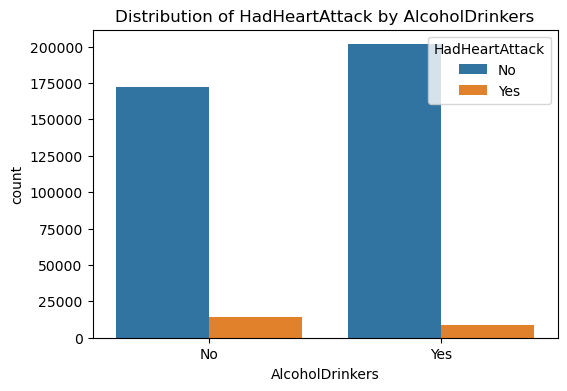

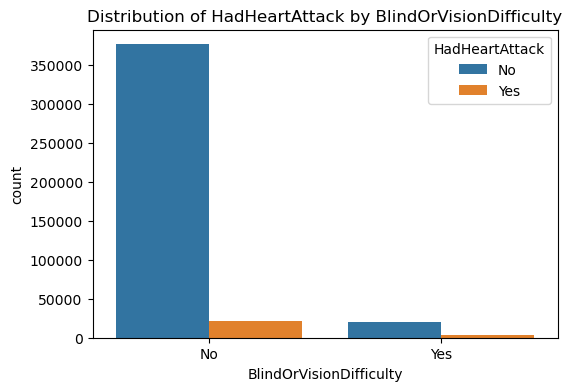

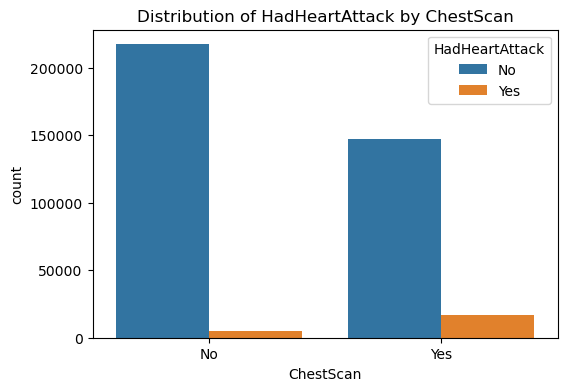

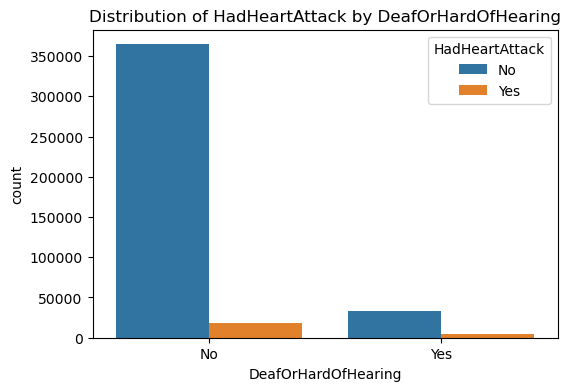

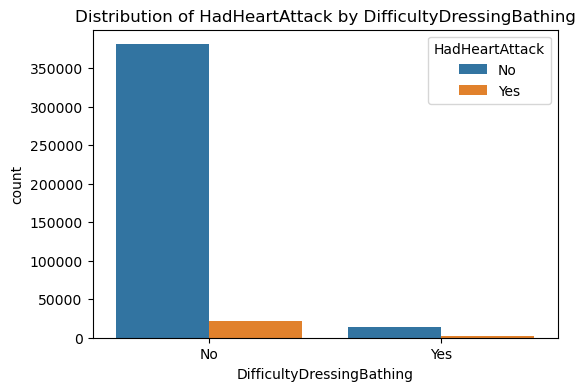

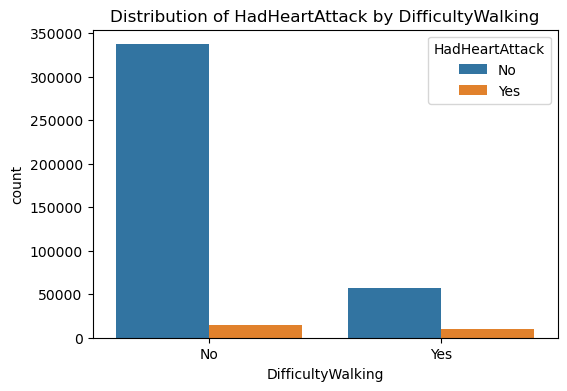

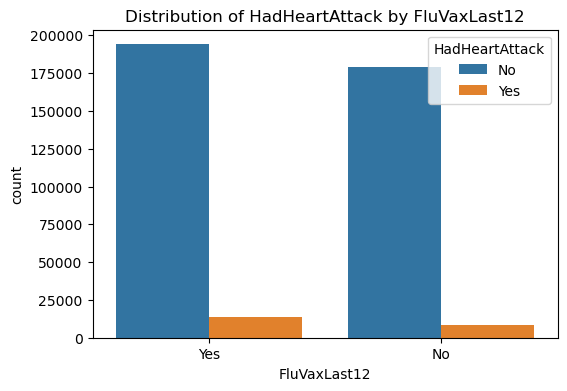

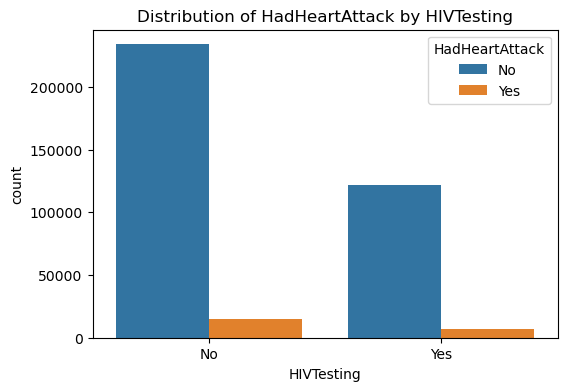

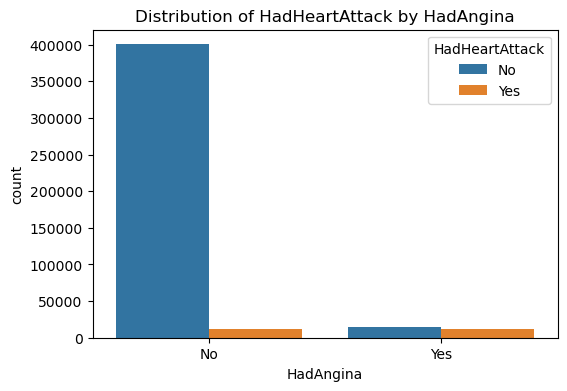

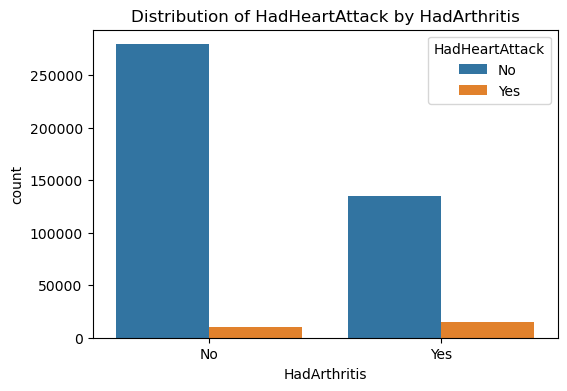

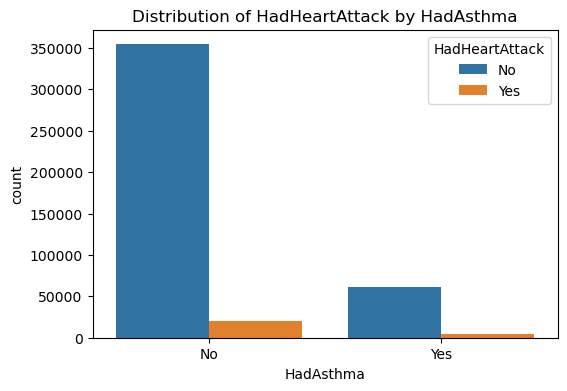

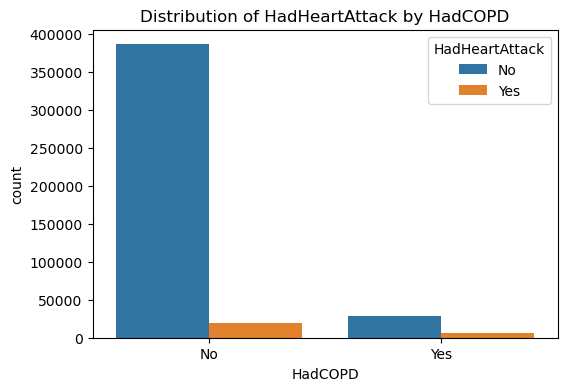

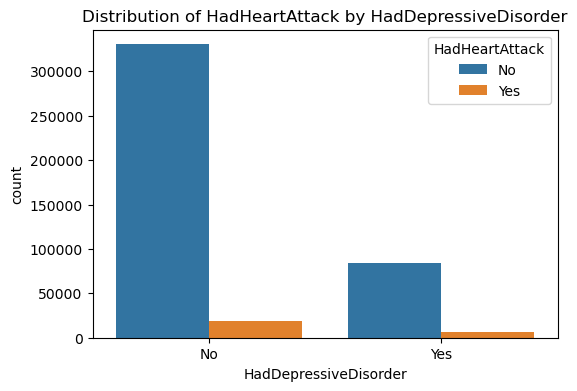

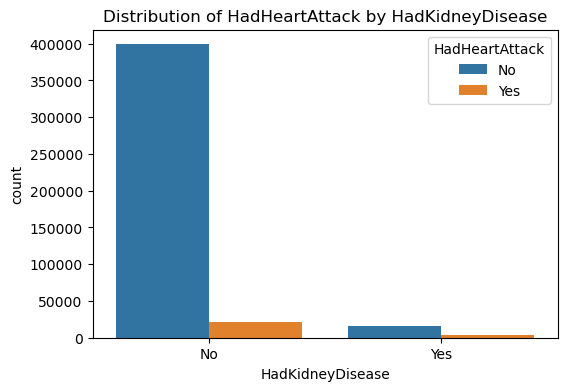

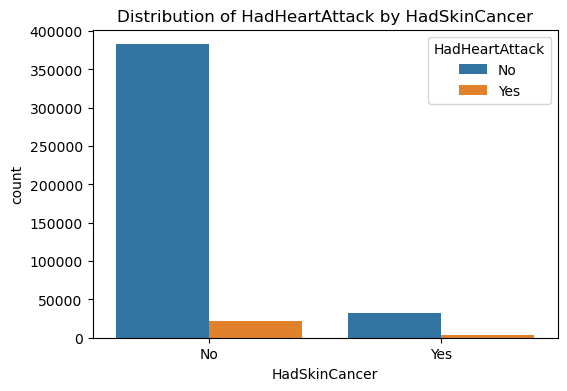

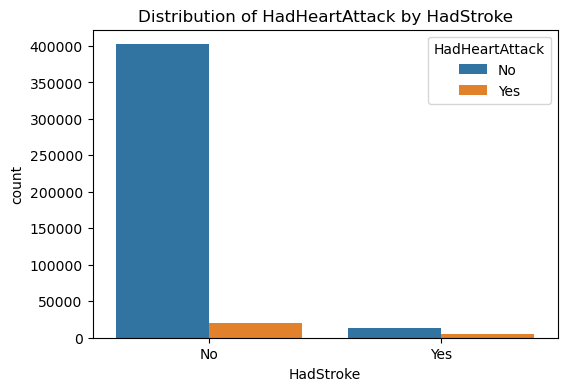

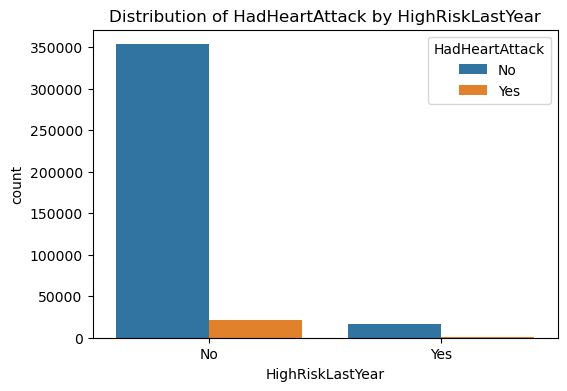

In [ ]:


for bool_column in boolean_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=bool_column, hue="HadHeartAttack")
    plt.title(f"Distribution of HadHeartAttack by {bool_column}")
    plt.show()

In [47]:
df["MentalHealthDays"].unique()

array([ 0.,  3.,  9.,  5., 15., 20., 14., 10., 18.,  1., nan,  2., 30.,
        4.,  6.,  7., 25.,  8., 22., 29., 27., 21., 12., 28., 16., 13.,
       26., 17., 11., 23., 19., 24.])

In [48]:
df_original = df.copy

In [49]:
encoder = LabelEncoder()
df["Sex"] = encoder.fit_transform(df["Sex"])

# show all unique values of the Gender column
print(df["Sex"].unique())
print("-" * 40)

# null values in each column
# print(df.isnull().sum().sort_values(ascending=False))
# print("-" * 40)

null_df = pd.DataFrame(columns = ["Column", "Null Count", "Null %"])

for col in df.columns.sort_values():
    null_count = df[col].isnull().sum()
    null_percent = (null_count / len(df)) * 100
    null_df.loc[len(null_df)] = [col, null_count, null_percent.round(2)]
    
    # print(f"Column: {col}")
    # print(f"  Null count: {null_count}")
    # print(f"  Null percentage: {null_percent:.2f}%")
    # print("-" * 40)

null_df.sort_values(by="Null %", ascending=False)


# # drop the columns with more than 10% null values
# df = df.dropna(thresh=0.9 * len(df))

# # drop the columns with all null values
# df = df.dropna(axis=1, how="all")

[0 1]
----------------------------------------


,Column,Null Count,Null %
38,TetanusLast10Tdap,82516,18.54
31,PneumoVaxEver,77040,17.31
14,HIVTesting,66127,14.86
4,ChestScan,56046,12.59
5,CovidPos,50764,11.40
26,HighRiskLastYear,50623,11.37
2,BMI,48806,10.96
12,FluVaxLast12,47121,10.59
1,AlcoholDrinkers,46574,10.46
39,WeightInKilograms,42078,9.45
